In [2]:
from keras.datasets.mnist import load_data
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
from sklearn.model_selection import train_test_split


X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=0.1)


In [5]:
import numpy as np

In [6]:
X_train_expanded = np.expand_dims(X_train, axis=3)

In [14]:
X_dev_expanded = np.expand_dims(X_dev, axis=3)

In [9]:
from tensorflow.keras.utils import to_categorical


y_train_new = to_categorical(y_train, num_classes=10)
y_dev_new = to_categorical(y_dev, num_classes = 10)


In [10]:
# Các thư viện cơ bản
import numpy as np
import matplotlib.pyplot as plt

# Các thành phần từ Keras/TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical

# Nếu bạn cần load dataset MNIST
from tensorflow.keras.datasets import mnist

# Bai 1

In [11]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, padding="valid", kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

optimizer = Adam(learning_rate=0.01)
loss = CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train_expanded, y_train_new, batch_size=128, epochs=20, validation_data=(X_dev_expanded,y_dev_new))

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8038 - loss: 6.1093 - val_accuracy: 0.9507 - val_loss: 0.1606
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9583 - loss: 0.1388 - val_accuracy: 0.9610 - val_loss: 0.1441
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9616 - loss: 0.1249 - val_accuracy: 0.9563 - val_loss: 0.1358
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9608 - loss: 0.1288 - val_accuracy: 0.9572 - val_loss: 0.1555
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9638 - loss: 0.1206 - val_accuracy: 0.9513 - val_loss: 0.1903
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9572 - loss: 0.1515 - val_accuracy: 0.9585 - val_loss: 0.1390
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9615 - loss: 0.1301 - val_accuracy: 0.9453 - val_loss: 0.1907
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9622 - loss: 0.1282 - val_accuracy: 0.

In [21]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 96.10%
Loss thấp nhất trên validation set: 0.1255


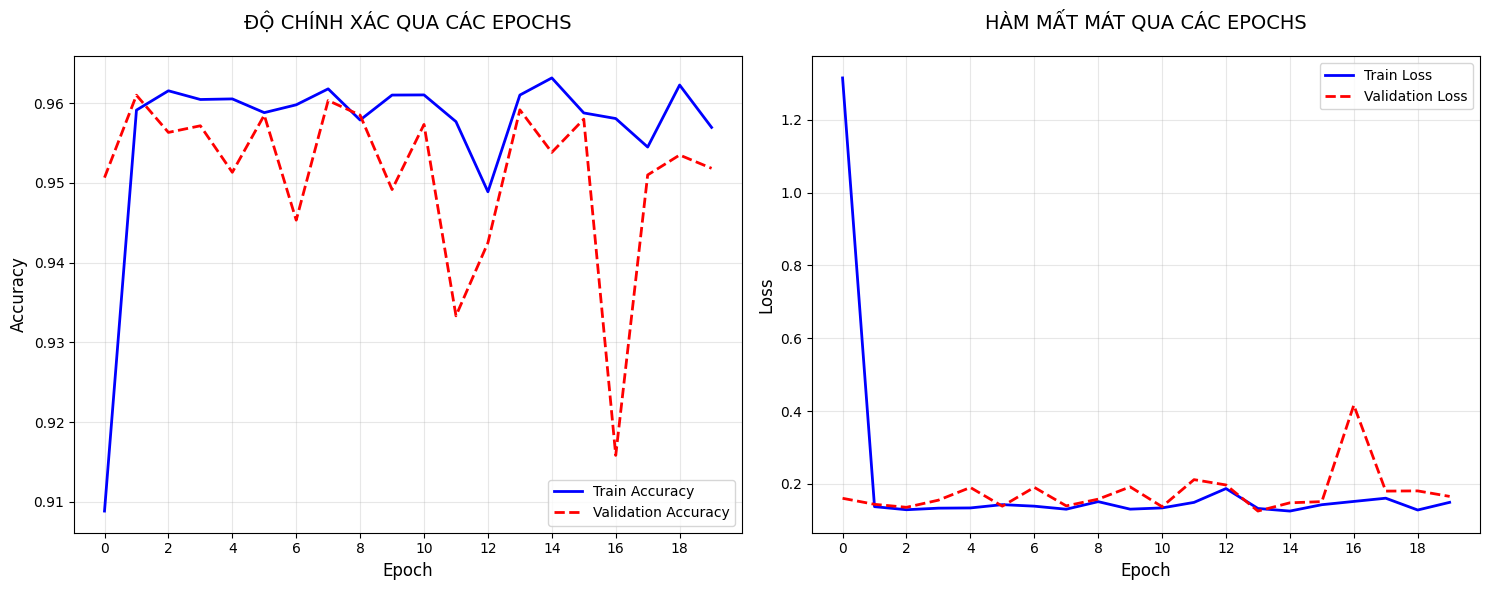

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
model = Sequential()
model.add(Conv2D(filters=6, kernel_size=(5,5),
padding='same', activation='relu',input_shape=(28,28,1)))
model.add(AveragePooling2D(strides=2, pool_size=(2, 2)))
model.add(Conv2D(filters=16, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(AveragePooling2D(strides=2, pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(120, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

optimizer = Adam(learning_rate=0.01)
loss = CategoricalCrossentropy()

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


# Bài 2: Hiện thực mô hình ở phần 3, sử dụng hàm activation tanh cho 2 lớp CONV. Thực hiện huấn luyện lại mô hình và xem kết quả? Cho biết độ chính xác và đồ thị học của mô hình.

In [23]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, padding="valid", kernel_size=(3, 3), activation="tanh"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="tanh"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

optimizer = Adam(learning_rate=0.01)
loss = CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])



In [24]:
history = model.fit(X_train_expanded, y_train_new, batch_size=128, epochs=20, validation_data=(X_dev_expanded,y_dev_new))

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8720 - loss: 0.4868 - val_accuracy: 0.9525 - val_loss: 0.2151
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9604 - loss: 0.1823 - val_accuracy: 0.9603 - val_loss: 0.2035
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9632 - loss: 0.2095 - val_accuracy: 0.9498 - val_loss: 0.4062
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9633 - loss: 0.2453 - val_accuracy: 0.9553 - val_loss: 0.3559
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9627 - loss: 0.2898 - val_accuracy: 0.9543 - val_loss: 0.4657
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9606 - loss: 0.3241 - val_accuracy: 0.9592 - val_loss: 0.4082
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9645 - loss: 0.3206 - val_accuracy: 0.9585 - val_loss: 0.4832
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9673 - loss: 0.2978 - val_accuracy: 0.

In [25]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 97.38%
Loss thấp nhất trên validation set: 0.2035


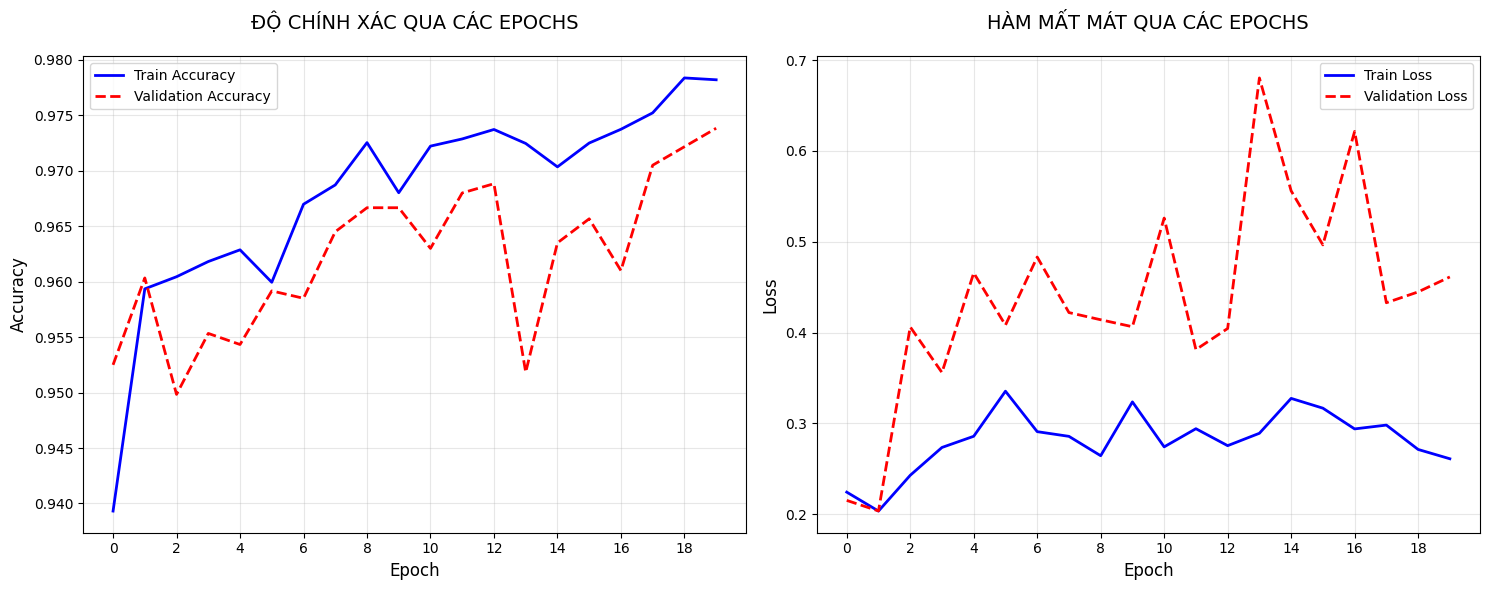

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Bài 3

In [28]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [29]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, padding="valid", kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))  # Thêm Dropout với tỷ lệ 50% trước lớp Dense
model.add(Dense(10, activation="softmax"))

optimizer = Adam(learning_rate=0.01)
loss = CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [30]:
history = model.fit(X_train_expanded, y_train_new, batch_size=128, epochs=20, validation_data=(X_dev_expanded,y_dev_new))

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6433 - loss: 4.7211 - val_accuracy: 0.9402 - val_loss: 0.2074
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8885 - loss: 0.3741 - val_accuracy: 0.9563 - val_loss: 0.1452
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9099 - loss: 0.3004 - val_accuracy: 0.9587 - val_loss: 0.1541
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9178 - loss: 0.2805 - val_accuracy: 0.9603 - val_loss: 0.1288
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9296 - loss: 0.2379 - val_accuracy: 0.9650 - val_loss: 0.1133
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9342 - loss: 0.2262 - val_accuracy: 0.9677 - val_loss: 0.1147
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9370 - loss: 0.2142 - val_accuracy: 0.9673 - val_loss: 0.1103
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9385 - loss: 0.2125 - val_accuracy: 0

In [31]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 96.95%
Loss thấp nhất trên validation set: 0.0984


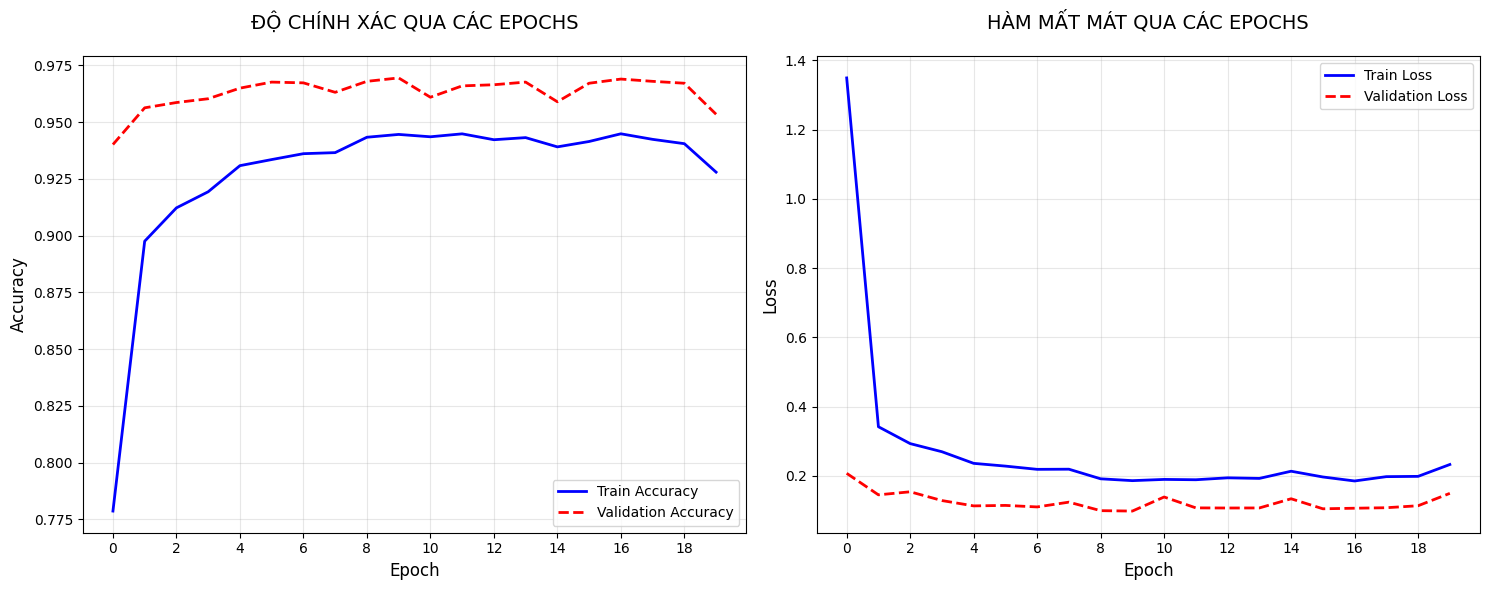

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Bài 4


In [33]:
model = Sequential()
model.add(Conv2D(filters=6, kernel_size=(5,5),
padding='same', activation='relu',input_shape=(28,28,1)))
model.add(AveragePooling2D(strides=2, pool_size=(2, 2)))
model.add(Conv2D(filters=16, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(AveragePooling2D(strides=2, pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(120, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

optimizer = Adam(learning_rate=0.01)
loss = CategoricalCrossentropy()

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


In [34]:
history = model.fit(X_train_expanded, y_train_new, batch_size=128, epochs=20, validation_data=(X_dev_expanded,y_dev_new))

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7695 - loss: 1.6824 - val_accuracy: 0.9563 - val_loss: 0.1439
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9659 - loss: 0.1120 - val_accuracy: 0.9587 - val_loss: 0.1394
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9722 - loss: 0.0963 - val_accuracy: 0.9622 - val_loss: 0.1359
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9734 - loss: 0.0927 - val_accuracy: 0.9742 - val_loss: 0.0946
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9752 - loss: 0.0841 - val_accuracy: 0.9605 - val_loss: 0.1436
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9771 - loss: 0.0835 - val_accuracy: 0.9623 - val_loss: 0.1557
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9756 - loss: 0.0908 - val_accuracy: 0.9765 - val_loss: 0.1052
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9799 - loss: 0.0725 - val_accuracy: 0

In [35]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 97.65%
Loss thấp nhất trên validation set: 0.0946


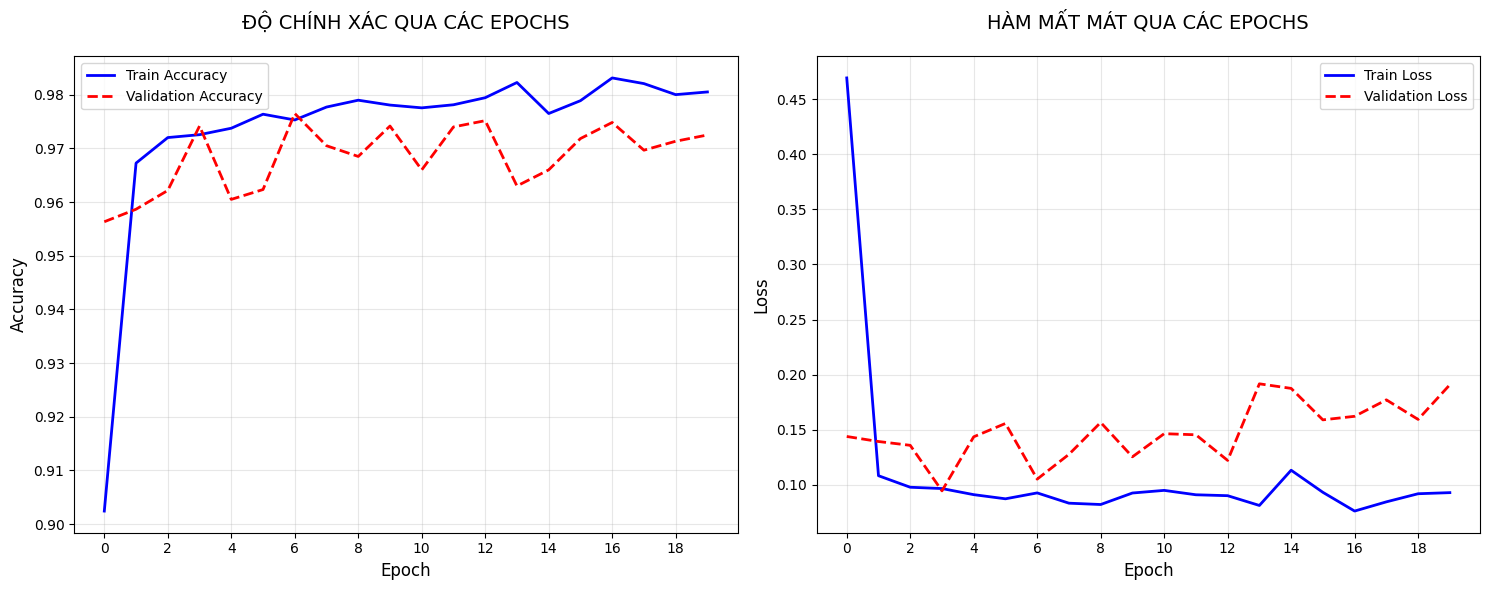

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# bài 5

In [37]:
from tensorflow.keras.models import load_model

model.save('model3.h5')


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
model = Sequential()

# Lớp 1: CONV2D
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(filters=96, kernel_size=(12, 12), strides=4, padding='same', activation='relu'))

# Lớp 2: MaxPooling2D
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Lớp 3: CONV2D
model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=1, padding='same', activation='relu'))

# Lớp 4: MaxPooling2D
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Lớp 5: CONV2D
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))

# Lớp 6: CONV2D
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))

# Lớp 7: CONV2D
model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))

# Lớp 8: MaxPooling2D
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Chuyển sang fully connected layers
model.add(Flatten())

# Lớp 9: Dropout
model.add(Dropout(0.5))

# Lớp 10: Dense
model.add(Dense(4096, activation='relu'))

# Lớp 11: Dense
model.add(Dense(4096, activation='relu'))

# Lớp 12: Dense (Output)
model.add(Dense(10, activation='softmax'))

# Biên dịch mô hình
optimizer = Adam(learning_rate=0.0001)  # Learning rate nhỏ hơn so với mạng nhỏ
loss = CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Hiển thị kiến trúc mô hình
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 96)       │        13,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 2, 2, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 2, 2, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,601,130 (82.40 MB)

 Trainable params: 21,601,130 (82.40 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(X_train_expanded, y_train_new, batch_size=128, epochs=20, validation_data=(X_dev_expanded,y_dev_new))

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.7233 - loss: 0.8287 - val_accuracy: 0.9650 - val_loss: 0.1235
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9689 - loss: 0.1042 - val_accuracy: 0.9730 - val_loss: 0.0888
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9797 - loss: 0.0700 - val_accuracy: 0.9782 - val_loss: 0.0697
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9852 - loss: 0.0507 - val_accuracy: 0.9753 - val_loss: 0.0868
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9875 - loss: 0.0413 - val_accuracy: 0.9798 - val_loss: 0.0752
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9842 - val_loss: 0.0553
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9913 - loss: 0.0307 - val_accuracy: 0.9750 - val_loss: 0.0955
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9920 - loss: 0.0257 - val_a

In [40]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 98.67%
Loss thấp nhất trên validation set: 0.0553


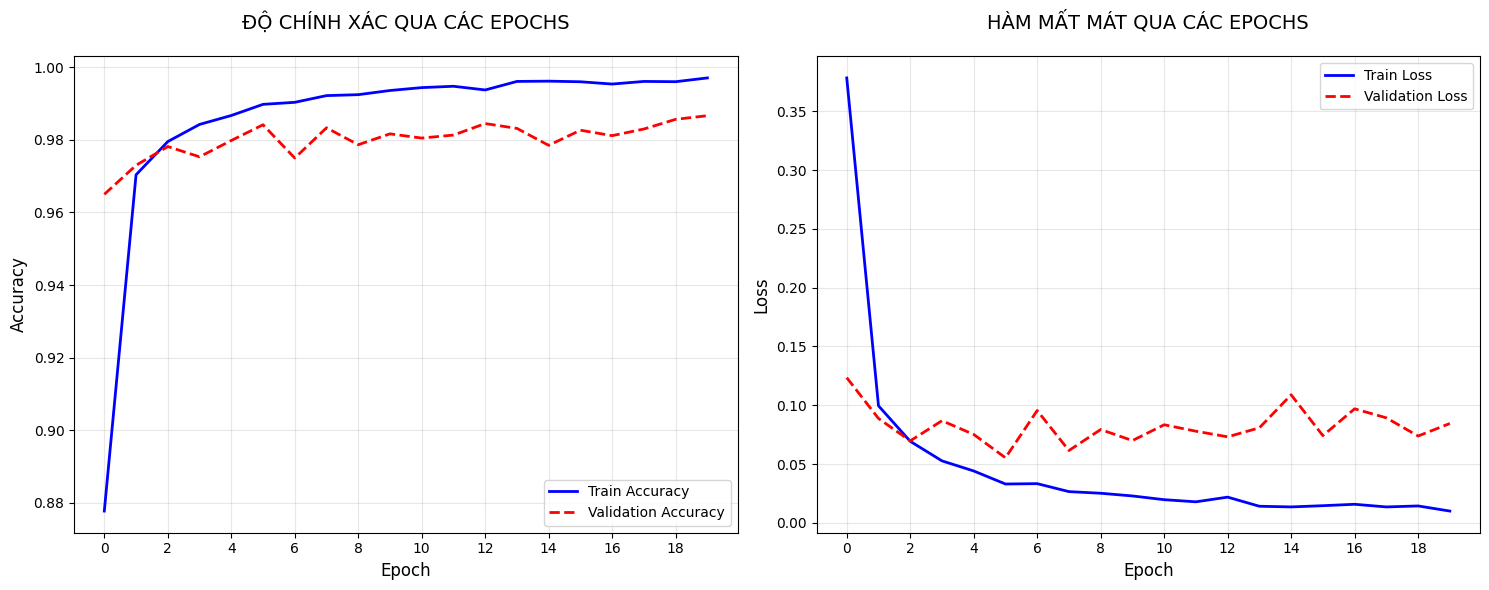

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# bai 7

In [43]:
from tensorflow.keras.datasets import cifar10

In [44]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [45]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [46]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [48]:
from tensorflow.keras.layers import BatchNormalization

In [50]:
model = Sequential()

# Lớp 1: CONV2D (điều chỉnh kernel size cho ảnh nhỏ)
model.add(Input(shape=(32, 32, 3)))  # CIFAR-10 có kích thước 32x32 với 3 channels
model.add(Conv2D(filters=96, kernel_size=(5, 5), strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())  # Thêm BatchNorm để ổn định huấn luyện
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Lớp 2: CONV2D
model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Lớp 3: CONV2D
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())

# Lớp 4: CONV2D
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())

# Lớp 5: CONV2D
model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))

# Chuyển sang fully connected layers
model.add(Flatten())

# Lớp 6: Dropout + Dense
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(BatchNormalization())

# Lớp 7: Dropout + Dense
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(BatchNormalization())

# Lớp đầu ra
model.add(Dense(10, activation='softmax'))

## 3. Biên dịch mô hình
optimizer = Adam(learning_rate=0.0001)  # Learning rate nhỏ
loss = CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Hiển thị kiến trúc
model.summary()

history = model.fit(X_train, y_train,
                    batch_size=128,
                    epochs=20,
                    validation_data=(X_test, y_test),
                    verbose=1)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác trên tập test: {test_acc*100:.2f}%")

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 37,361,418 (142.52 MB)

 Trainable params: 37,342,282 (142.45 MB)

 Non-trainable params: 19,136 (74.75 KB)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 91ms/step - accuracy: 0.3544 - loss: 2.1146 - val_accuracy: 0.1330 - val_loss: 3.3420
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.5328 - loss: 1.4394 - val_accuracy: 0.6176 - val_loss: 1.1069
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6220 - loss: 1.1125 - val_accuracy: 0.6159 - val_loss: 1.1152
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.6841 - loss: 0.9114 - val_accuracy: 0.7067 - val_loss: 0.8773
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.7211 - loss: 0.8010 - val_accuracy: 0.7254 - val_loss: 0.8307
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.7627 - loss: 0.6787 - val_accuracy: 0.7426 - val_loss: 0.7839
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.7912 - loss: 0.6055 - val_accuracy: 0.7163 - val_loss: 0.8677
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.8162 - loss: 0.5220 - 

In [51]:
# Độ chính xác cao nhất trên tập validation
max_val_acc = max(history.history['val_accuracy'])
print(f"\nĐộ chính xác cao nhất trên validation set: {max_val_acc*100:.2f}%")

# Loss thấp nhất trên tập validation
min_val_loss = min(history.history['val_loss'])
print(f"Loss thấp nhất trên validation set: {min_val_loss:.4f}")


Độ chính xác cao nhất trên validation set: 78.65%
Loss thấp nhất trên validation set: 0.7648


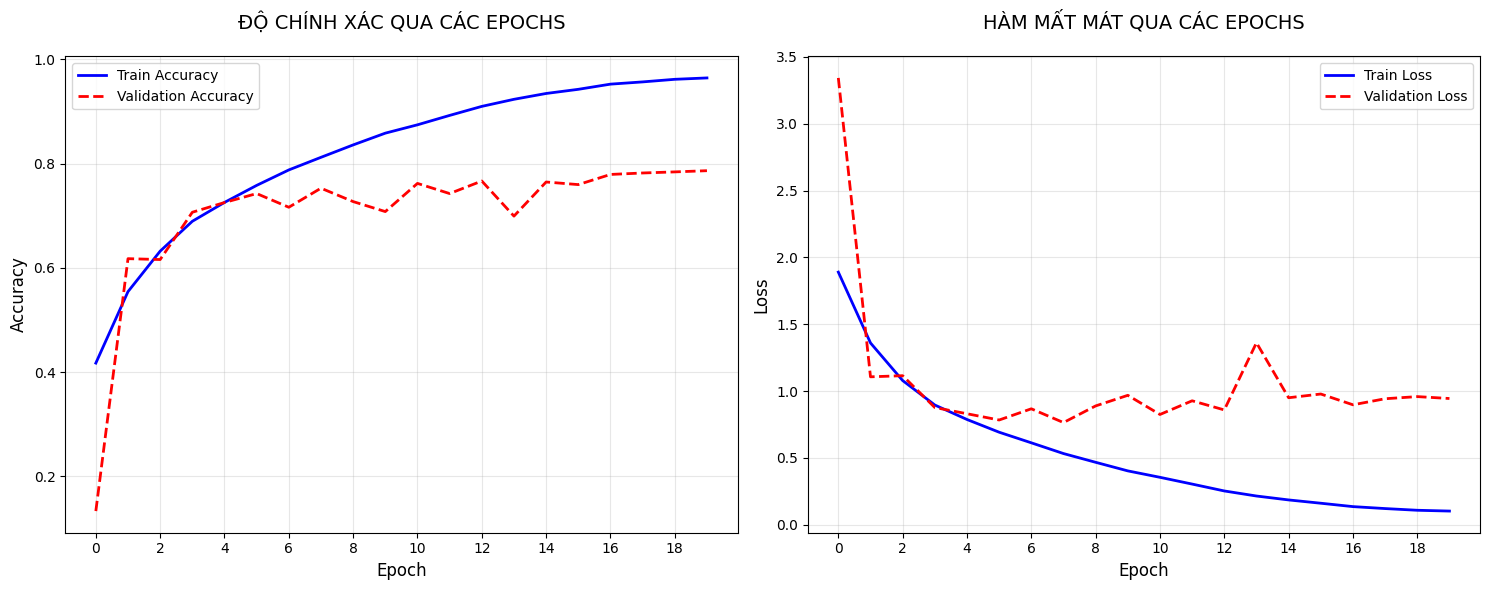

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='dashed', linewidth=2)
plt.title('ĐỘ CHÍNH XÁC QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('HÀM MẤT MÁT QUA CÁC EPOCHS', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(np.arange(0, 20, 2))  # Hiển thị mỗi 2 epoch
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()